### HuyIGW04 - Gradient Boost

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('dataset/london_energy.csv', delimiter=',')
print(df.head())
df.isna().sum()

       LCLid        Date     KWH
0  MAC000002  2012-10-12   7.098
1  MAC000002  2012-10-13  11.087
2  MAC000002  2012-10-14  13.223
3  MAC000002  2012-10-15  10.257
4  MAC000002  2012-10-16   9.769


LCLid    0
Date     0
KWH      0
dtype: int64

In [2]:
df = df.groupby('Date')['KWH'].mean()
df.head()

Date
2011-11-23     6.952692
2011-11-24     8.536480
2011-11-25     9.499781
2011-11-26    10.267707
2011-11-27    10.850805
Name: KWH, dtype: float64

In [3]:
new_df = pd.DataFrame({'date': df.index.tolist(), 'consumption': df.values.tolist()})
new_df.head()

,date,consumption
0,2011-11-23,6.952692
1,2011-11-24,8.536480
2,2011-11-25,9.499781
3,2011-11-26,10.267707
4,2011-11-27,10.850805


<Axes: xlabel='date'>

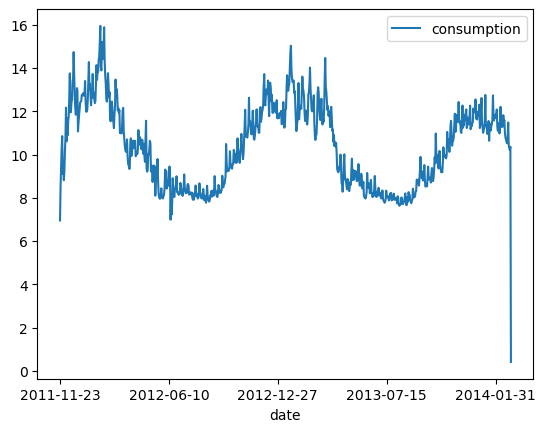

In [4]:
new_df.plot(x='date', y='consumption')

In [5]:
new_df['date'] = pd.to_datetime(new_df['date'])
print(new_df.head())
new_df['date'].dtype

        date  consumption
0 2011-11-23     6.952692
1 2011-11-24     8.536480
2 2011-11-25     9.499781
3 2011-11-26    10.267707
4 2011-11-27    10.850805


dtype('<M8[ns]')

<Axes: xlabel='date'>

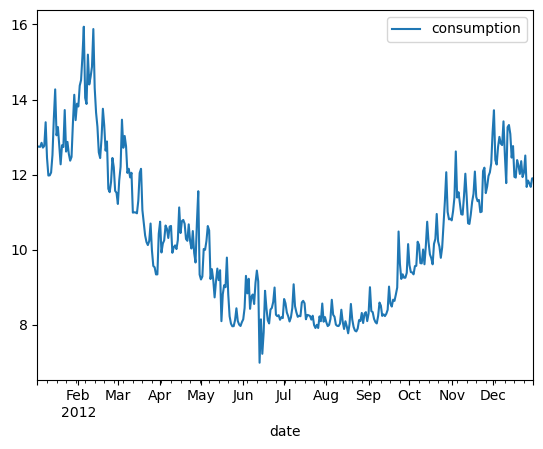

In [6]:
new_df.query("date < '2013-01-01' & date > '2012-01-01'").plot(x='date', y='consumption')

In [7]:
new_df['day_of_week'] = new_df['date'].dt.day_of_week
new_df['day_of_year'] = new_df['date'].dt.day_of_year
new_df['month'] = new_df['date'].dt.month
new_df['quarter'] = new_df['date'].dt.quarter
new_df['year'] = new_df['date'].dt.year
print(new_df.head())
print(f'from: {new_df['date'].min()}')
print(f'to: {new_df['date'].max()}')

        date  consumption  day_of_week  day_of_year  month  quarter  year
0 2011-11-23     6.952692            2          327     11        4  2011
1 2011-11-24     8.536480            3          328     11        4  2011
2 2011-11-25     9.499781            4          329     11        4  2011
3 2011-11-26    10.267707            5          330     11        4  2011
4 2011-11-27    10.850805            6          331     11        4  2011
from: 2011-11-23 00:00:00
to: 2014-02-28 00:00:00


In [8]:
# 2013-08-06
train_set = new_df.query('date < "2013-08-06"')
test_set = new_df.query('date > "2013-08-05"')
print(train_set.shape)
print(train_set.head())
print(test_set.shape)
print(test_set.head())

(622, 7)
        date  consumption  day_of_week  day_of_year  month  quarter  year
0 2011-11-23     6.952692            2          327     11        4  2011
1 2011-11-24     8.536480            3          328     11        4  2011
2 2011-11-25     9.499781            4          329     11        4  2011
3 2011-11-26    10.267707            5          330     11        4  2011
4 2011-11-27    10.850805            6          331     11        4  2011
(207, 7)
          date  consumption  day_of_week  day_of_year  month  quarter  year
622 2013-08-06     7.714011            1          218      8        3  2013
623 2013-08-07     7.633054            2          219      8        3  2013
624 2013-08-08     7.667107            3          220      8        3  2013
625 2013-08-09     7.693745            4          221      8        3  2013
626 2013-08-10     7.703308            5          222      8        3  2013


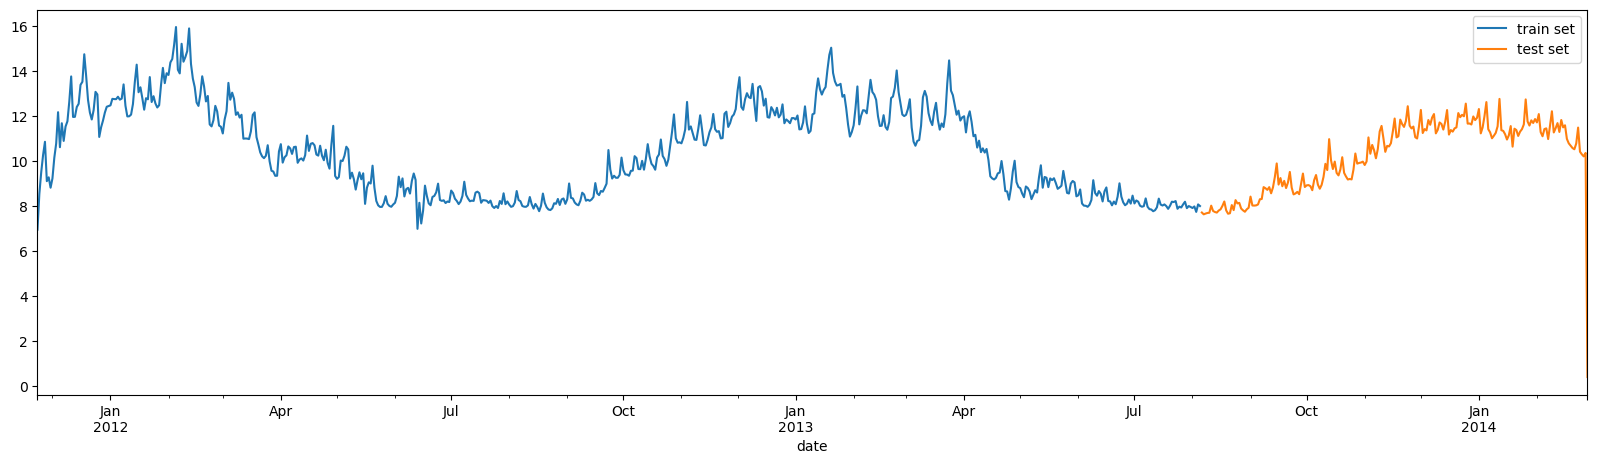

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,5))
train_set.plot(ax=ax, label='train set', x='date', y='consumption')
test_set.plot(ax=ax, label='test set', x='date', y='consumption')
plt.show()

In [10]:
train_set.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year
0,2011-11-23,6.952692,2,327,11,4,2011
1,2011-11-24,8.536480,3,328,11,4,2011
2,2011-11-25,9.499781,4,329,11,4,2011
3,2011-11-26,10.267707,5,330,11,4,2011
4,2011-11-27,10.850805,6,331,11,4,2011


In [11]:
train_set = train_set.drop(columns='date')
train_set.head()

test_date = test_set["date"]
test_set = test_set.drop(columns=["date"])


In [12]:
X_train = train_set.loc[:, ['day_of_week','day_of_year','month','quarter','year']]
print(X_train.shape)
y_train = train_set['consumption']
print(y_train.shape)

# test set
X_test = test_set.loc[:, ['day_of_week','day_of_year','month','quarter','year']]
print(X_test.shape)
y_test = test_set['consumption']
print(y_test.shape)

(622, 5)
(622,)
(207, 5)
(207,)


In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cv_split = TimeSeriesSplit(n_splits=4, test_size=100)
parameter = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [100, 300],
}
gd_model = GradientBoostingRegressor()

grid_search = GridSearchCV(estimator=gd_model, param_grid=parameter, cv=cv_split)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=100),
             estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, 5],
                         'n_estimators': [100, 300]})

In [14]:
prediction = grid_search.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse,\
      mean_absolute_percentage_error as mape, accuracy_score
print(f'MAE score: {mae(prediction, y_test)}')
print(f'MSE score: {mse(prediction, y_test)}')
print(f'MAPE score: {mape(prediction, y_test)}')

MAE score: 0.7331073372760464
MSE score: 1.2869170661291107
MAPE score: 0.06582124381891016


In [16]:
print(test_date.shape)
print(y_test.shape)
print(prediction.shape)

(207,)
(207,)
(207,)


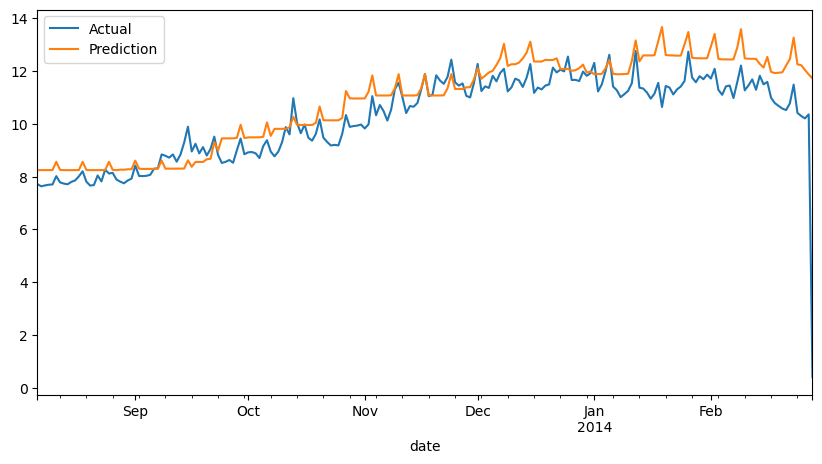

In [17]:
df_test = pd.DataFrame({"date": test_date, "actual": y_test, "prediction": prediction })
figure, ax = plt.subplots(figsize=(10, 5))
df_test.plot(ax=ax, label="Actual", x="date", y="actual")
df_test.plot(ax=ax, label="Prediction", x="date", y="prediction")
plt.legend(["Actual", "Prediction"])
plt.show()